In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [5]:
df = pd.read_csv(r'E:\Data Science\FP using python\Bestseller Books.csv')
df_clean= df.copy()


### 1. Data Loading and Data Preparation


In [4]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3380 entries, 0 to 3379
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         3380 non-null   object 
 1   Year         3380 non-null   float64
 2   Author       3380 non-null   object 
 3   User Rating  3380 non-null   float64
 4   Reviews      3380 non-null   float64
 5   Price ($)    3380 non-null   float64
 6   Genre        3380 non-null   object 
dtypes: float64(4), object(3)
memory usage: 185.0+ KB


In [3]:
df_clean.describe()

,Year,User Rating,Reviews,Price ($)
count,3380.000000,3380.000000,3380.000000,3380.000000
mean,2013.957988,4.278831,60769.160059,26.307692
std,3.156472,0.329791,46311.302644,10.006464
min,2009.000000,3.500000,0.000000,0.000000
25%,2011.000000,4.050000,27740.500000,19.500000
50%,2014.000000,4.300000,49961.500000,26.000000
75%,2017.000000,4.500000,85219.750000,33.000000
max,2019.000000,5.000000,345257.000000,63.500000


### 2. Exploratory analysis & visualization

<Axes: title={'center': 'Distribution of  Books by User Rating'}, xlabel='User Rating', ylabel='Count'>

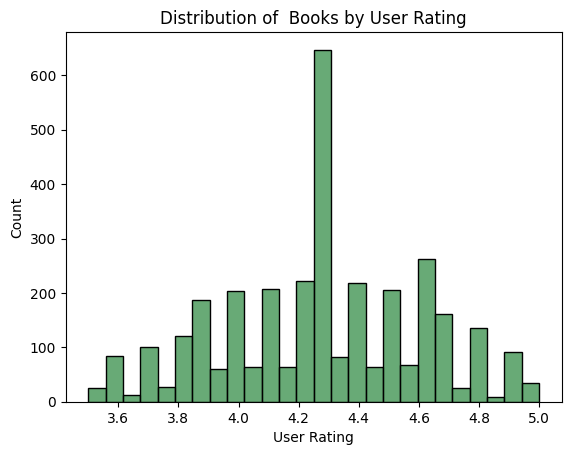

In [12]:
sns.set_palette("PRGn_r")
plt.title("Distribution of  Books by User Rating")
sns.histplot(df['User Rating'],edgecolor='black')

<Axes: title={'center': 'CDF plot for user ratings'}, xlabel='User Rating', ylabel='Proportion'>

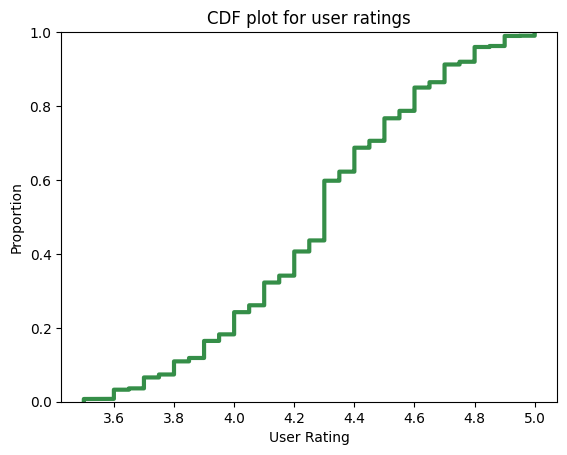

In [13]:
plt.title("CDF plot for user ratings")
sns.ecdfplot(df['User Rating'],linewidth=3)

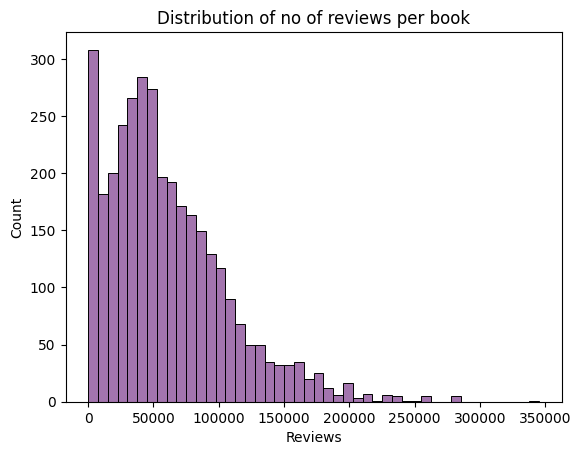

In [14]:
sns.set_palette("PRGn")
plt.title("Distribution of no of reviews per book")
sns.histplot(df['Reviews'],edgecolor='black');

<Axes: title={'center': 'CDF plot for no of reviews'}, xlabel='No of reviews', ylabel='Proportion'>

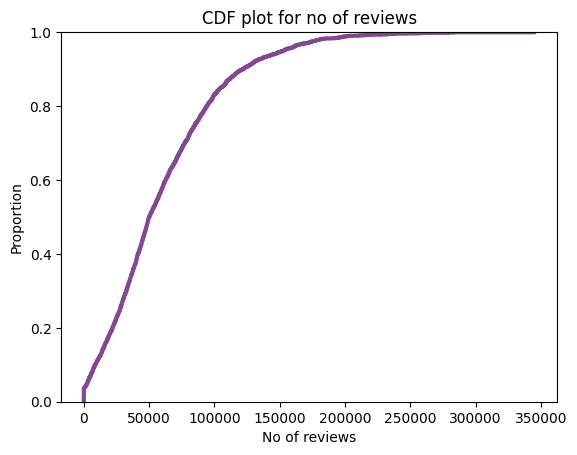

In [15]:
plt.xlabel("No of reviews")
plt.title("CDF plot for no of reviews")
sns.ecdfplot(df.Reviews,linewidth=3)

<Axes: title={'center': 'Distribution of price per book'}, xlabel='Price ($)', ylabel='Count'>

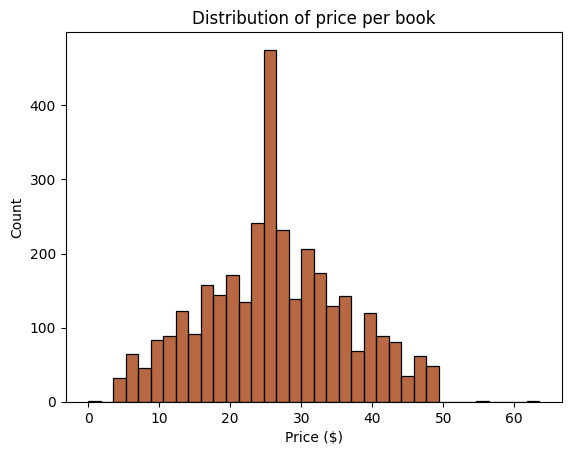

In [17]:
sns.set_palette("YlOrBr_r")
plt.title("Distribution of price per book")
sns.histplot(df['Price ($)'],edgecolor='black')

<Axes: title={'center': 'CDF plot for prices of books'}, xlabel='Price ($)', ylabel='Proportion'>

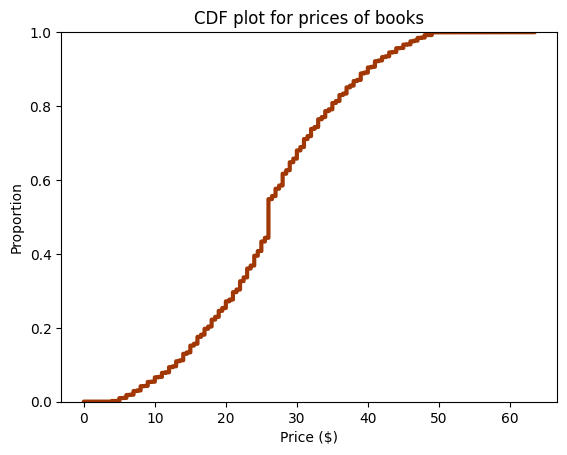

In [20]:
plt.title("CDF plot for prices of books")
sns.ecdfplot(df['Price ($)'],linewidth=3)

<Axes: title={'center': 'Year-wise user ratings of books'}, xlabel='Year', ylabel='User Rating'>

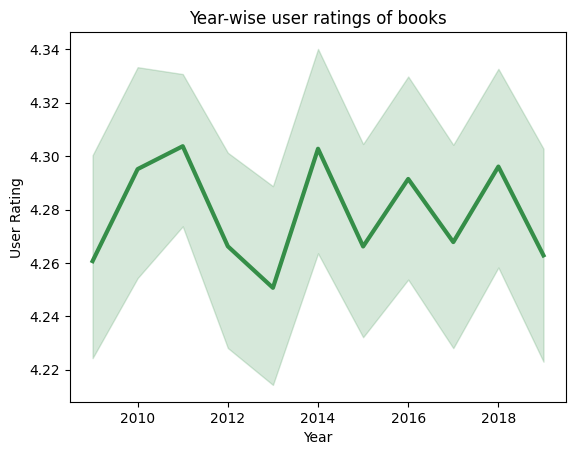

In [21]:
sns.set_palette("PRGn_r")
plt.title("Year-wise user ratings of books")
sns.lineplot(y="User Rating", x="Year", data=df,linewidth=3)

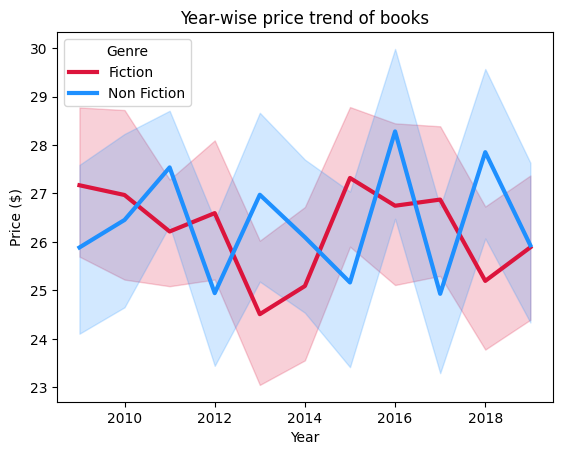

In [22]:
custom_palette = ['crimson',"dodgerblue"]
sns.set_palette(custom_palette)
plt.title("Year-wise price trend of books")
sns.lineplot(y="Price ($)", x="Year",hue="Genre", data=df,linewidth=3);

<Axes: title={'center': 'Year-wise no of reviews of books'}, xlabel='Year', ylabel='Reviews'>

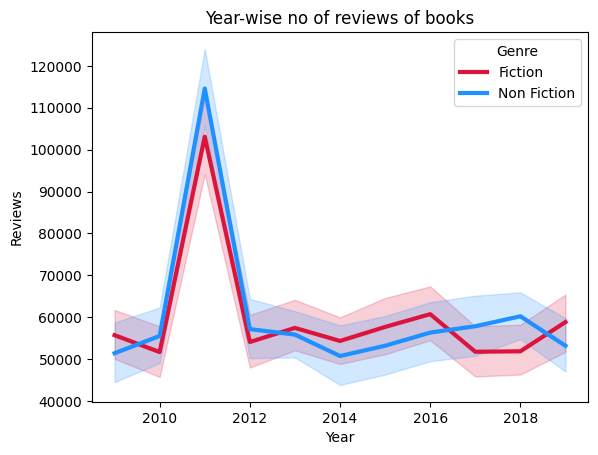

In [23]:
custom_palette = ['crimson',"dodgerblue"]
sns.set_palette(custom_palette)
plt.title("Year-wise no of reviews of books")
sns.lineplot(y="Reviews", x="Year", hue="Genre" ,data=df,linewidth=3)

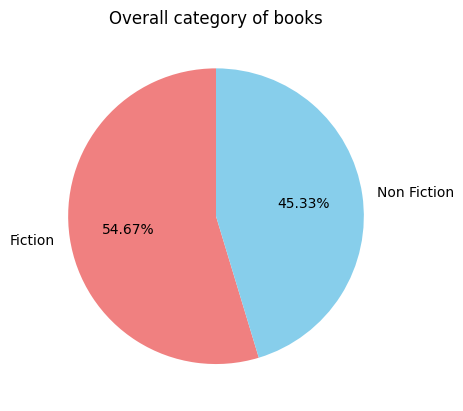

In [24]:
custom_palette = ['lightcoral',"skyblue"]
sns.set_palette(custom_palette)
genre = df.Genre.value_counts()
plt.title("Overall category of books")
plt.pie(genre, labels=genre.index, autopct='%0.2f%%', startangle=90);

### 3. Asking and answering questions

#### 1. Top 10 bestselling books from 2009 to 2019 (fiction/non-fiction)

C:\Users\c.delivery for lap\AppData\Local\Temp\ipykernel_13160\3648102007.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


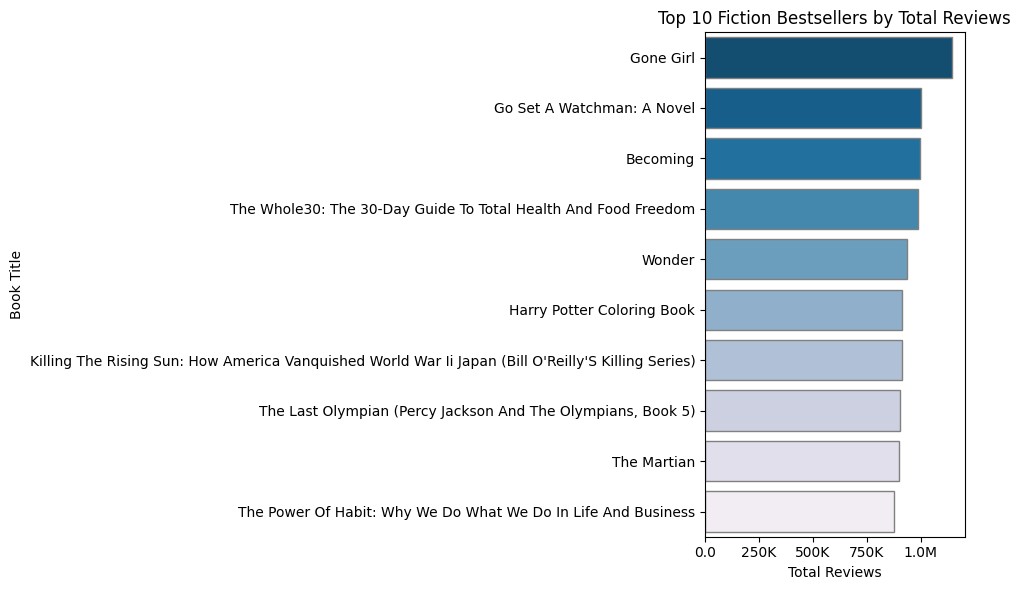

In [47]:
# Filter for Fiction genre
fict = df[df['Genre'] == 'Fiction']

# Group by book, calculate appearances and total reviews
fict_grouped = fict.groupby('Name').agg({
    'Year': 'count',
    'Reviews': 'sum'
}).rename(columns={'Year': 'Appearances', 'Reviews': 'Total_Reviews'}).reset_index()

# Sort by total reviews and select top 10
top10fict = fict_grouped.sort_values(by='Total_Reviews', ascending=False).head(10)

# Plotting the data
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10fict,
    x='Total_Reviews',
    y='Name',
    palette='PuBu_r',
    edgecolor='grey'
)
plt.title("Top 10 Fiction Bestsellers by Total Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Book Title")

# Format X-axis labels (e.g., 100000 to 100K)
ax = plt.gca()
def human_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    else:
        return str(x)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_format))

plt.tight_layout()
plt.show()

C:\Users\c.delivery for lap\AppData\Local\Temp\ipykernel_13160\3562204987.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


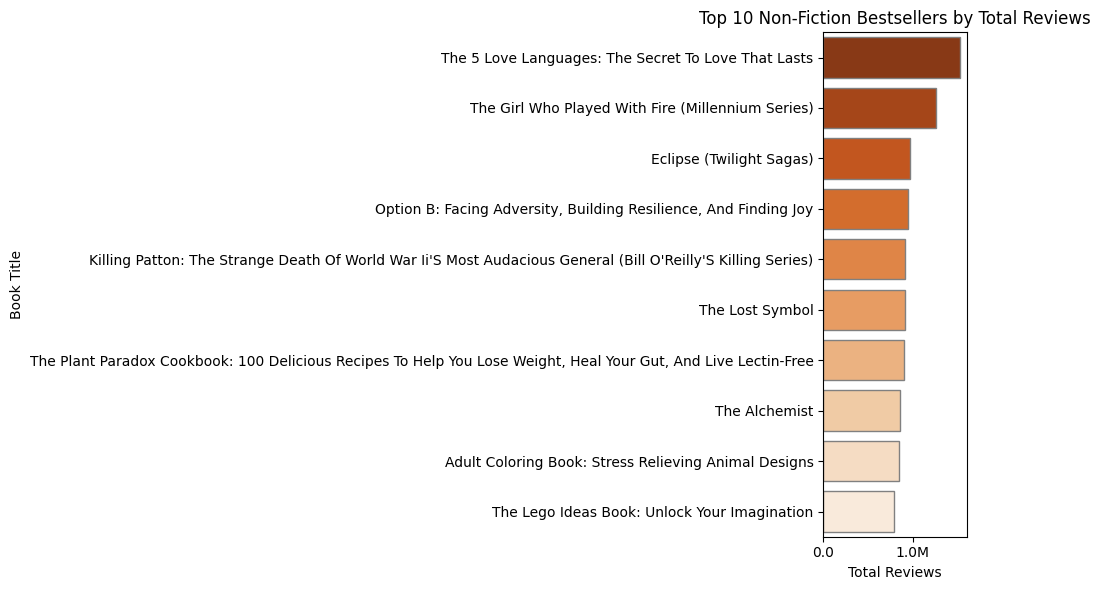

In [46]:
# Filter for Non-Fiction books
nonfict = df[df['Genre'] == 'Non Fiction']

# Group by book name and aggregate
nonfict_grouped = nonfict.groupby('Name').agg({
    'Year': 'count',
    'Reviews': 'sum'
}).rename(columns={'Year': 'Appearances', 'Reviews': 'Total_Reviews'}).reset_index()

# Get the top 10 by total reviews
top10nonfict = nonfict_grouped.sort_values(by='Total_Reviews', ascending=False).head(10)

# Plotting the data
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10nonfict,
    x='Total_Reviews',
    y='Name',
    palette='Oranges_r',
    edgecolor='grey'
)
plt.title("Top 10 Non-Fiction Bestsellers by Total Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Book Title")

# Format X-axis labels (e.g., 100000 to 100K)
ax = plt.gca()
def human_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    else:
        return str(x)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_format))

plt.tight_layout()
plt.show()

#### 2. Top 10 bestselling authors from 2009 to 2019 (fiction/non-fiction)

In [36]:

top10fict_auth = fict['Author'].value_counts().head(10)
top10nonfict_auth = nonfict['Author'].value_counts().head(10)

C:\Users\c.delivery for lap\AppData\Local\Temp\ipykernel_13160\2697531763.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10fict_auth,y=top10fict_auth.index, palette = 'PuBu_r',edgecolor='grey');


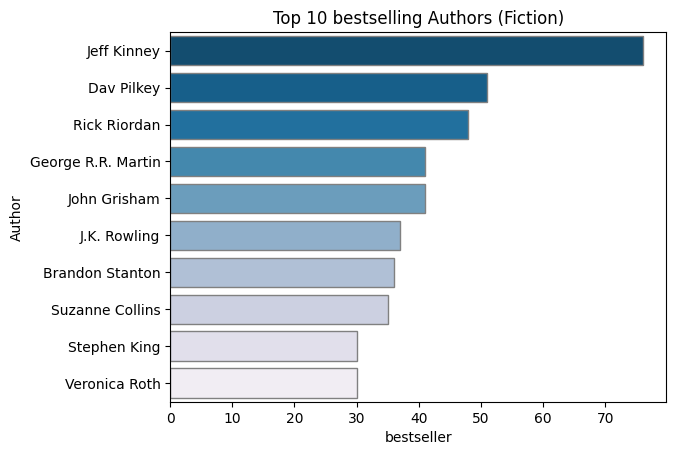

In [35]:
sns.barplot(x=top10fict_auth,y=top10fict_auth.index, palette = 'PuBu_r',edgecolor='grey');
plt.title("Top 10 bestselling Authors (Fiction)")
plt.xlabel('bestseller');

C:\Users\c.delivery for lap\AppData\Local\Temp\ipykernel_13160\180166436.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10nonfict_auth,y=top10nonfict_auth.index, palette = 'OrRd_r',edgecolor='grey');


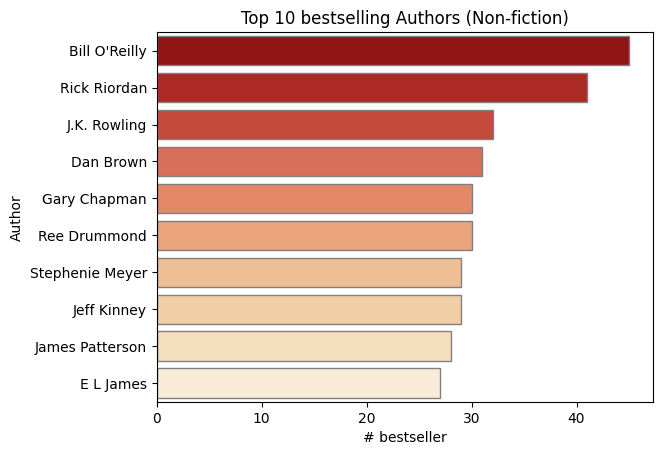

In [48]:
sns.barplot(x=top10nonfict_auth,y=top10nonfict_auth.index, palette = 'OrRd_r',edgecolor='grey');
plt.title("Top 10 bestselling Authors (Non-fiction)")
plt.xlabel('# bestseller');

#### 3. Year-wise percentage category distribution of books

In [49]:
temp1 = df.groupby(['Year','Genre'])[['Genre']].count()
temp1.rename(columns={"Genre":'Count'},inplace=True)
temp1.reset_index(inplace= True)

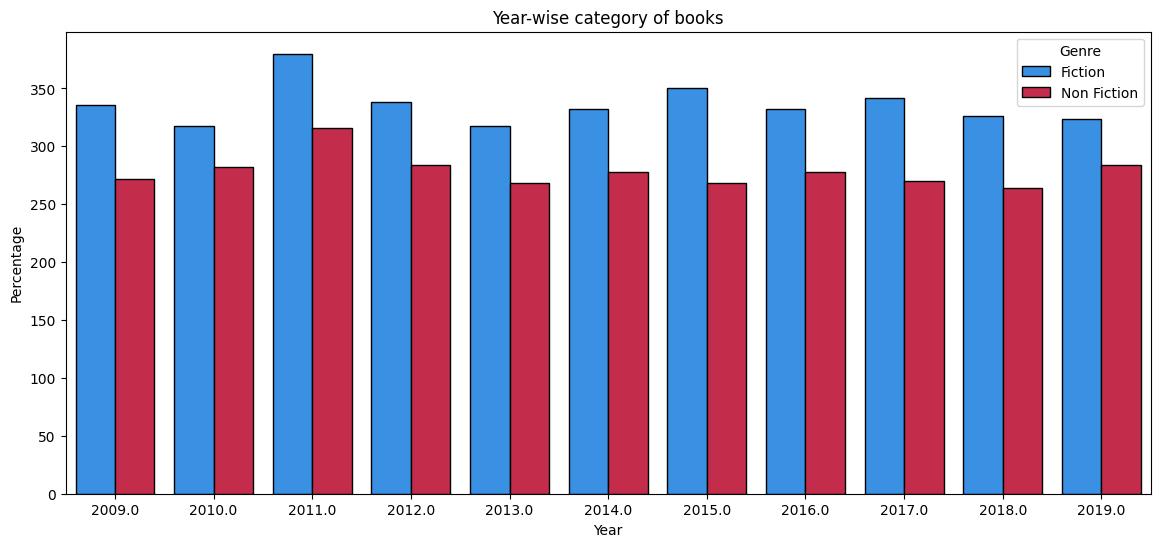

In [51]:
custom_palette = ["dodgerblue",'crimson']
sns.set_palette(custom_palette)
plt.figure(figsize=(14,6))
plt.title("Year-wise category of books")
sns.barplot(x=temp1.Year, y=temp1.Count * 100 / 50, hue=temp1.Genre,edgecolor='black');
plt.ylabel("Percentage");


#### 4. How many unique books and authors were included in bestsellers list from 2009 to 2019?

In [54]:
uniquebook = df.Name.nunique()
uniqueauth = df.Author.nunique()
print(uniquebook,3380-uniquebook)
print(uniqueauth)

348 3032
232


#### 5. Most expensive book and most affordable book

In [59]:
temp2 = df[df['Price ($)'] == df['Price ($)'].max()]
exp=temp2.drop_duplicates(subset=['Name'], keep='first')
exp[['Name','Author','Price ($)']]

,Name,Author,Price ($)
551,Diagnostic And Statistical Manual Of Mental Di...,American Psychiatric Association,63.5


In [60]:
exp.Name.tolist()

['Diagnostic And Statistical Manual Of Mental Disorders, 5Th Edition: Dsm-5']

In [62]:
temp3 = df[df['Price ($)'] == df['Price ($)'].min()]
cheap=temp3.drop_duplicates(subset=['Name'], keep='first')
cheap[['Name','Author','Price ($)']]

,Name,Author,Price ($)
3106,To Kill A Mockingbird,Harper Lee,0.0


#### 6. Highest rated and lowest rated books

In [64]:
temp4 = df[df['User Rating'] == df['User Rating'].max()]
highrated = temp4.drop_duplicates(subset=['Name'], keep='first')
highrated[['Name','Author','User Rating']]

,Name,Author,User Rating
46,"5,000 Awesome Facts (About Everything!) (Natio...",John Grisham,5.0
216,And The Mountains Echoed,Khaled Hosseini,5.0
261,Baby Touch And Feel: Animals,Dk,5.0
279,Barefoot Contessa Foolproof: Recipes You Can T...,Ina Garten,5.0
379,Calm The F*Ck Down: An Irreverent Adult Colori...,Sasha O'Hara,5.0
432,Crazy Rich Asians (Crazy Rich Asians Trilogy),Kevin Kwan,5.0
463,Cutting For Stone,Abraham Verghese,5.0
492,Dead And Gone: A Sookie Stackhouse Novel (Sook...,Charlaine Harris,5.0
502,Dead In The Family (Sookie Stackhouse/True Blo...,Charlaine Harris,5.0
655,Dog Man And Cat Kid: From The Creator Of Capta...,Dav Pilkey,5.0


In [65]:
len(highrated.Name.tolist())

32

In [66]:
temp5 = df[df['User Rating'] == df['User Rating'].min()]
lowrated = temp5.drop_duplicates(subset=['Name'], keep='first')
lowrated[['Name','Author','User Rating']]

,Name,Author,User Rating
331,Born To Run,Bruce Springsteen,3.5
426,Crazy Love: Overwhelmed By A Relentless God,Francis Chan,3.5
442,Creative Haven Creative Cats Coloring Book (Ad...,Phil Robertson,3.5
459,Cutting For Stone,Abraham Verghese,3.5
516,Dear Zoo: A Lift-The-Flap Book,Rod Campbell,3.5
549,Diagnostic And Statistical Manual Of Mental Di...,American Psychiatric Association,3.5
564,"Diary Of A Wimpy Kid: Hard Luck, Book 8",Jeff Kinney,3.5
581,Diary Of A Wimpy Kid: The Long Haul,Jeff Kinney,3.5
1031,Good Days Start With Gratitude: A 52 Week Guid...,Brandon Stanton,3.5
1127,"Harry Potter And The Cursed Child, Parts 1 & 2...",James Patterson,3.5


In [67]:
len(lowrated.Name.tolist())

24